# Лабораторная работа: Нормальное распределение в машинном обучении. От теории к практике.

**Цель:** Научиться работать с нормальным распределением как с инструментом анализа данных, а не как с абстрактной формулой.

---

## 0. Инициализация окружения и импорт библиотек

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Эстетика визуализации
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

np.random.seed(42)
print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## ЗАДАНИЕ 1. Центральная предельная теорема (ЦПТ) — доказательство «на пальцах»

### Теоретическая часть:
Центральная предельная теорема (ЦПТ) утверждает, что сумма большого числа независимых одинаково распределенных случайных величин с конечной дисперсией $\sigma^2$ стремится к нормальному распределению:
$$ S_n = \sum_{i=1}^n X_i \xrightarrow{d} \mathcal{N}(n\mu, n\sigma^2) $$

Для равномерного распределения $X \sim \mathcal{U}(0, 1)$:
- $\mathbb{E}[X] = 0.5$
- $\mathrm{Var}(X) = \frac{1}{12} \approx 0.08333$
- Для суммы 50 слагаемых: $\mathbb{E}[S_{50}] = 50 \times 0.5 = 25$, $\mathrm{Var}(S_{50}) = 50 / 12 \approx 4.1667$, $\sigma = \sqrt{50/12} \approx 2.0412$.

In [12]:
# 1. Моделирование U(0, 1) и суммы 50 слагаемых
sample_size = 50_000
n_sum = 50

single_uniform = np.random.uniform(0, 1, sample_size)
samples_50 = np.random.uniform(0, 1, (sample_size, n_sum)).sum(axis=1)

mu_theor_50 = n_sum * 0.5
std_theor_50 = np.sqrt(n_sum / 12.0)

print(f"Теоретические параметры: mean={mu_theor_50:.4f}, std={std_theor_50:.4f}")
print(f"Эмпирические параметры:   mean={np.mean(samples_50):.4f}, std={np.std(samples_50):.4f}")
print(f"Асимметрия (Skewness):   {stats.skew(samples_50):.5f}")
print(f"Эксцесс (Kurtosis):      {stats.kurtosis(samples_50):.5f}")

Теоретические параметры: mean=25.0000, std=2.0412
Эмпирические параметры:   mean=24.9999, std=2.0508
Асимметрия (Skewness):   -0.00379
Эксцесс (Kurtosis):      -0.02636


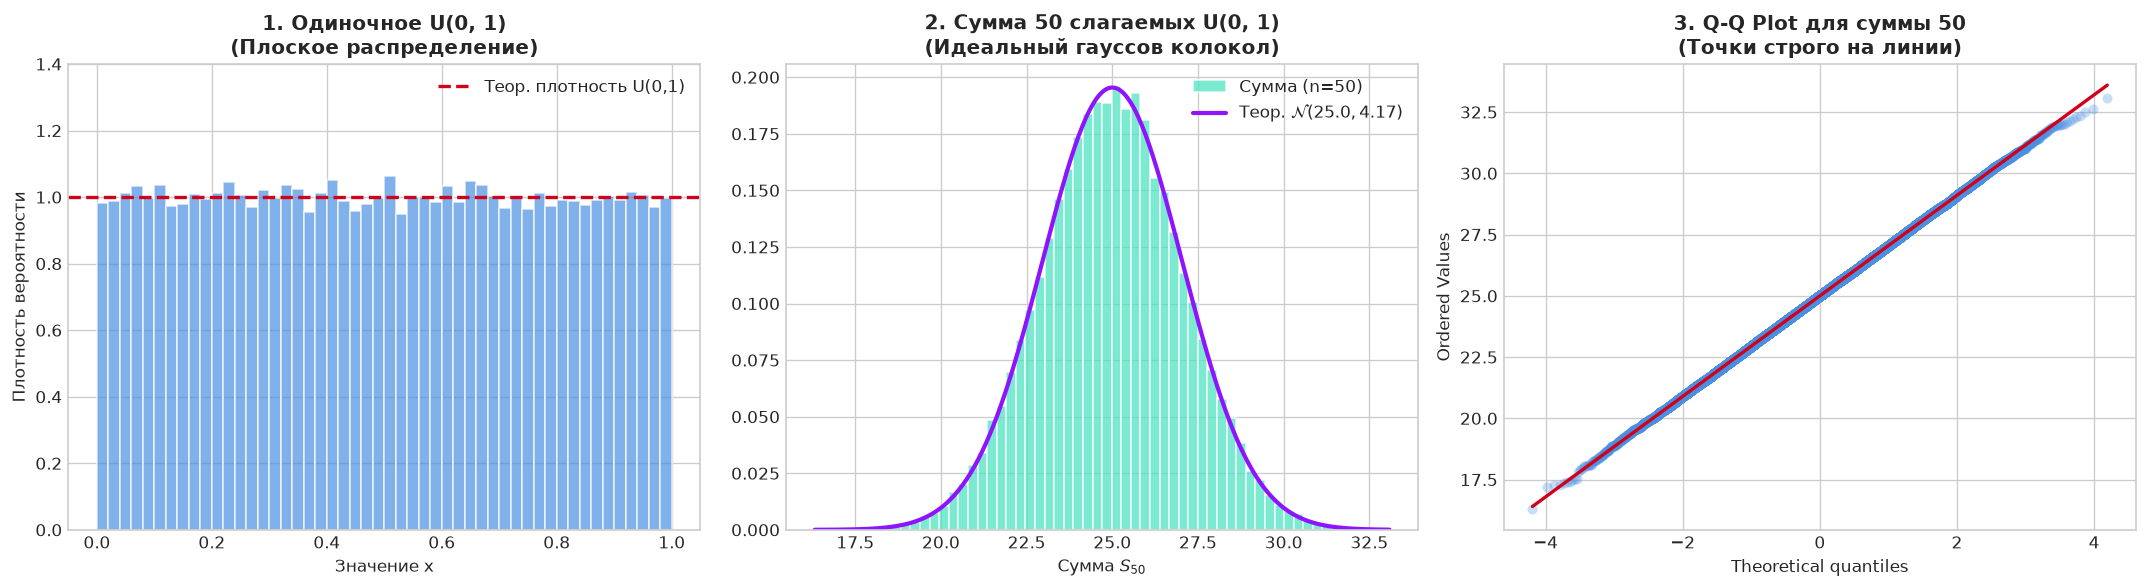

In [13]:
# 2. Визуализация: U(0,1) vs Сумма 50 vs Q-Q plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. U(0, 1)
axes[0].hist(single_uniform, bins=50, density=True, color='#4A90E2', alpha=0.7, edgecolor='white')
axes[0].axhline(1.0, color='#D0021B', linestyle='--', linewidth=2, label='Теор. плотность U(0,1)')
axes[0].set_title("1. Одиночное U(0, 1)\n(Плоское распределение)", fontweight='bold')
axes[0].set_xlabel("Значение x")
axes[0].set_ylabel("Плотность вероятности")
axes[0].legend()
axes[0].set_ylim(0, 1.4)

# 2. Сумма 50
count, bins, _ = axes[1].hist(samples_50, bins=60, density=True, color='#50E3C2', alpha=0.75,
                              edgecolor='white', label=f'Сумма (n={n_sum})')
x_grid = np.linspace(bins[0], bins[-1], 300)
axes[1].plot(x_grid, stats.norm.pdf(x_grid, loc=mu_theor_50, scale=std_theor_50), color='#9013FE', linewidth=2.5,
             label=rf'Теор. $\mathcal{{N}}({mu_theor_50:.1f}, {std_theor_50**2:.2f})$')
axes[1].set_title(f"2. Сумма {n_sum} слагаемых U(0, 1)\n(Идеальный гауссов колокол)", fontweight='bold')
axes[1].set_xlabel(rf"Сумма $S_{{{n_sum}}}$")
axes[1].legend()

# 3. Q-Q Plot
stats.probplot(samples_50, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_markerfacecolor('#4A90E2')
axes[2].get_lines()[0].set_markeredgecolor('none')
axes[2].get_lines()[0].set_alpha(0.3)
axes[2].get_lines()[1].set_color('#D0021B')
axes[2].get_lines()[1].set_linewidth(2)
axes[2].set_title(f"3. Q-Q Plot для суммы {n_sum}\n(Точки строго на линии)", fontweight='bold')

plt.tight_layout()
plt.show()

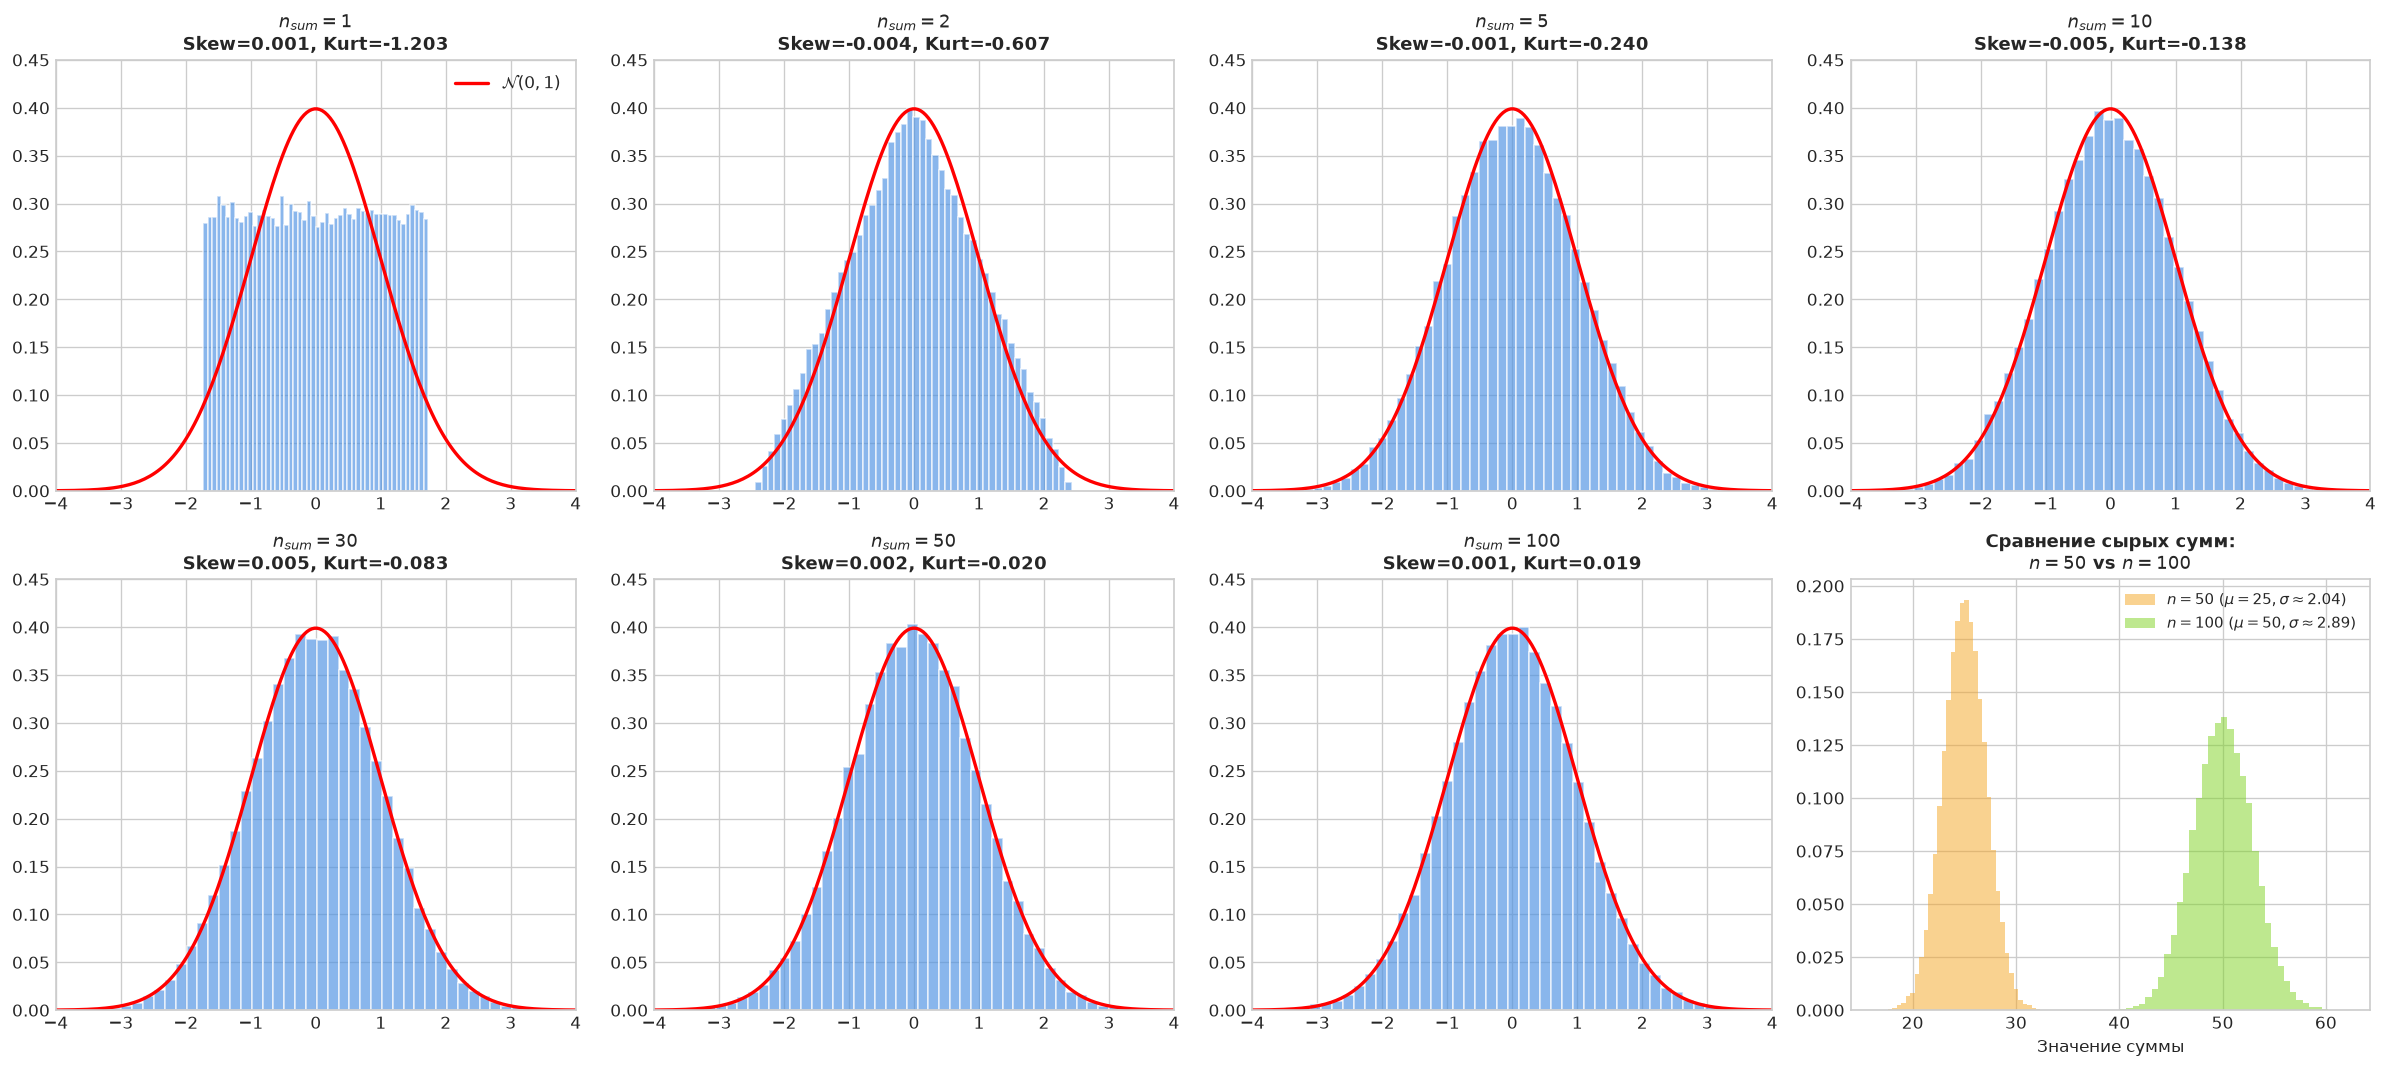

In [14]:
# 3. Исследование n_sum: [1, 2, 5, 10, 30, 50, 100]
n_sums = [1, 2, 5, 10, 30, 50, 100]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, n in enumerate(n_sums):
    raw_sums = np.random.uniform(0, 1, (sample_size, n)).sum(axis=1)
    z_scores = (raw_sums - n * 0.5) / np.sqrt(n / 12.0)
    
    ax = axes[idx]
    ax.hist(z_scores, bins=50, density=True, alpha=0.65, color='#4A90E2', edgecolor='white')
    z_grid = np.linspace(-4, 4, 200)
    ax.plot(z_grid, stats.norm.pdf(z_grid, 0, 1), 'r-', lw=2, label=r'$\mathcal{N}(0, 1)$')
    
    sk = stats.skew(raw_sums)
    kt = stats.kurtosis(raw_sums)
    ax.set_title(rf"$n_{{sum}} = {n}$" + f"\nSkew={sk:.3f}, Kurt={kt:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 0.45)
    if idx == 0:
        ax.legend(loc='upper right')

# Сравнение сырых сумм для n=50 и n=100
raw_50 = np.random.uniform(0, 1, (sample_size, 50)).sum(axis=1)
raw_100 = np.random.uniform(0, 1, (sample_size, 100)).sum(axis=1)
ax8 = axes[7]
ax8.hist(raw_50, bins=40, density=True, alpha=0.5, color='#F5A623', label=r'$n=50$ ($\mu=25, \sigma \approx 2.04$)')
ax8.hist(raw_100, bins=40, density=True, alpha=0.5, color='#7ED321', label=r'$n=100$ ($\mu=50, \sigma \approx 2.89$)')
ax8.set_title("Сравнение сырых сумм:\n$n=50$ vs $n=100$", fontsize=11, fontweight='bold')
ax8.set_xlabel("Значение суммы")
ax8.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

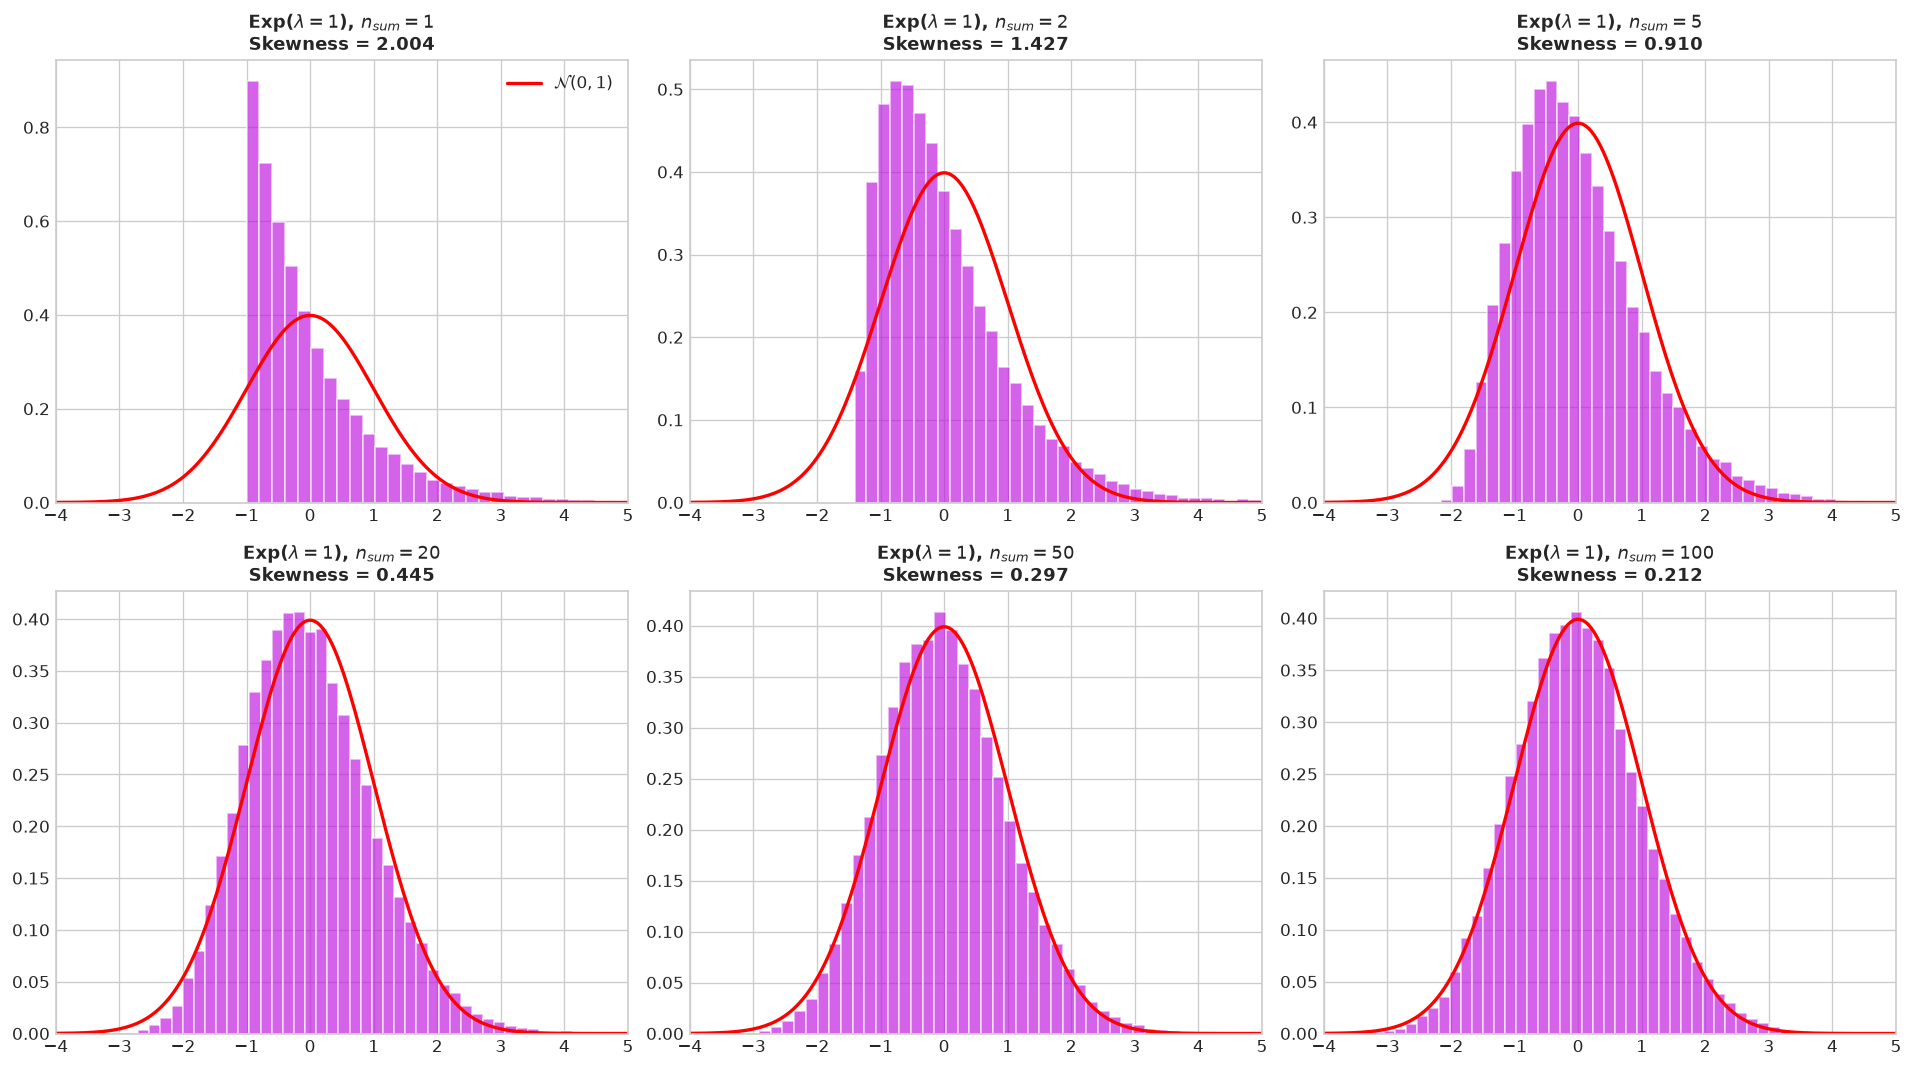

In [15]:
# 4. Сравнение с экспоненциальным распределением (Exp(lambda=1))
exp_ns = [1, 2, 5, 20, 50, 100]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, n in enumerate(exp_ns):
    exp_sums = np.random.exponential(scale=1.0, size=(sample_size, n)).sum(axis=1)
    z_exp = (exp_sums - n * 1.0) / np.sqrt(n * 1.0)

    ax = axes[idx]
    ax.hist(z_exp, bins=50, density=True, alpha=0.65, color='#BD10E0', edgecolor='white')
    z_grid = np.linspace(-4, 5, 200)
    ax.plot(z_grid, stats.norm.pdf(z_grid, 0, 1), 'r-', lw=2, label=r'$\mathcal{N}(0, 1)$')

    sk = stats.skew(exp_sums)
    ax.set_title(rf"Exp($\lambda=1$), $n_{{sum}} = {n}$" + f"\nSkewness = {sk:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlim(-4, 5)
    if idx == 0:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## ЗАДАНИЕ 2. Исследование влияния параметров на хвосты распределения

### Теоретическая часть:
В генеративных состязательных сетях (GAN) шум $z \sim \mathcal{N}(0, I)$ подается на вход генератора.
По правилу трех сигм ($3\sigma$) в стандартном нормальном распределении $\mathcal{N}(0, 1)$:
- $P(|x| \le 3) \approx 99.73\%$
- $P(|x| > 3) \approx 0.27\%$

При изменении $\sigma$ вероятность выброса равна:
$$ P(|X| > 3) = 2 \cdot \left(1 - \Phi\left(\frac{3}{\sigma}\right)\right) = 2 \cdot \mathrm{sf}\left(\frac{3}{\sigma}\right) $$

In [16]:
# 1. Моделирование вероятности выбросов |x| > 3 для разных sigma
sample_size_task2 = 100_000
threshold = 3.0
sigmas = np.arange(0.1, 3.05, 0.05)

emp_probs = []
theor_probs = []

for s in sigmas:
    samples = np.random.normal(loc=0.0, scale=s, size=sample_size_task2)
    emp_probs.append(np.mean(np.abs(samples) > threshold))
    theor_probs.append(2 * stats.norm.sf(threshold / s))

emp_probs = np.array(emp_probs)
theor_probs = np.array(theor_probs)

# Аналитическое нахождение sigma для P(|x| > 3) = 5%
sigma_5pct = threshold / stats.norm.ppf(0.975)
print(f"Критическое значение sigma для P(|x| > 3) = 5%: {sigma_5pct:.4f} (приблизительно 1.53)")
print(f"Вероятность при sigma = 1.0 (стандартный GAN):  {2 * stats.norm.sf(3.0 / 1.0) * 100:.3f}%")
print(f"Вероятность при sigma = 2.0:                     {2 * stats.norm.sf(3.0 / 2.0) * 100:.3f}%")
print(f"Вероятность при sigma = 0.5:                     {2 * stats.norm.sf(3.0 / 0.5) * 100:.6f}%")

Критическое значение sigma для P(|x| > 3) = 5%: 1.5306 (приблизительно 1.53)
Вероятность при sigma = 1.0 (стандартный GAN):  0.270%
Вероятность при sigma = 2.0:                     13.361%
Вероятность при sigma = 0.5:                     0.000000%


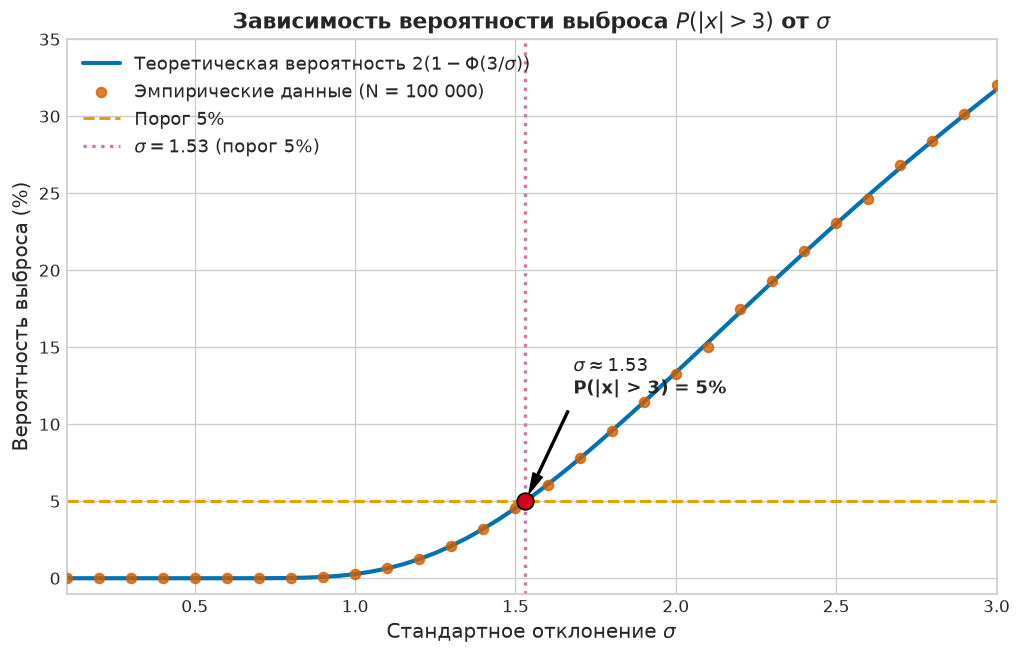

In [17]:
# 2. График зависимости вероятности выброса от sigma
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sigmas, theor_probs * 100, label=r'Теоретическая вероятность $2(1 - \Phi(3/\sigma))$',
        color='#0072B2', linewidth=2.5)
ax.scatter(sigmas[::2], emp_probs[::2] * 100, color='#D55E00', s=35, alpha=0.8,
           label='Эмпирические данные (N = 100 000)', zorder=4)

ax.axhline(5.0, color='#E69F00', linestyle='--', linewidth=1.8, label='Порог 5%')
ax.axvline(sigma_5pct, color='#CC79A7', linestyle=':', linewidth=2,
           label=rf'$\sigma = {sigma_5pct:.2f}$ (порог 5%)')

ax.scatter([sigma_5pct], [5.0], color='#D0021B', s=100, zorder=5, edgecolor='black')
ax.annotate(rf'$\sigma \approx {sigma_5pct:.2f}$' + '\nP(|x| > 3) = 5%',
            xy=(sigma_5pct, 5.0), xytext=(sigma_5pct + 0.15, 12.0),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
            fontweight='bold', fontsize=11)

ax.set_title(r'Зависимость вероятности выброса $P(|x| > 3)$ от $\sigma$', fontsize=13, fontweight='bold')
ax.set_xlabel(r'Стандартное отклонение $\sigma$', fontsize=12)
ax.set_ylabel('Вероятность выброса (%)', fontsize=12)
ax.set_xlim(0.1, 3.0)
ax.set_ylim(-1, 35)
ax.legend(loc='upper left', fontsize=11)
plt.show()

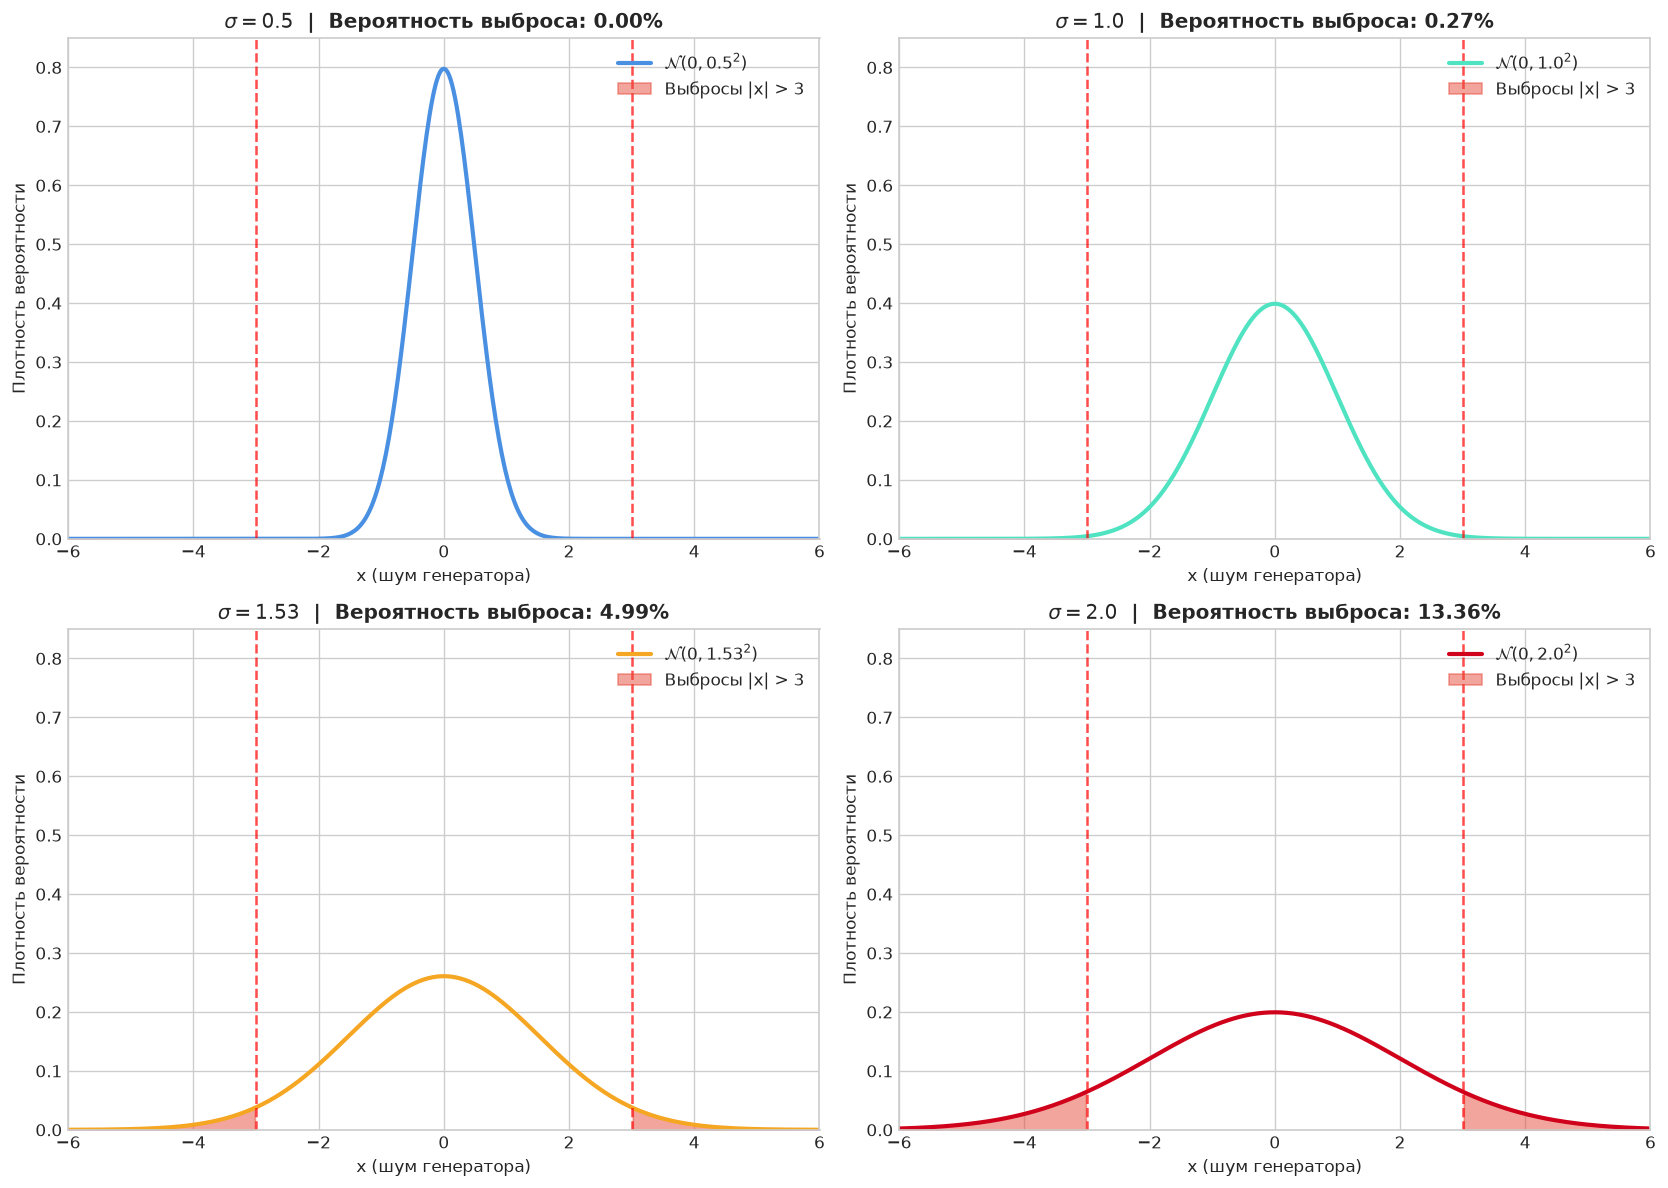

In [18]:
# 3. Визуализация хвостов распределений для sigma = [0.5, 1.0, 1.53, 2.0]
sigmas_compare = [0.5, 1.0, round(sigma_5pct, 2), 2.0]
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
x_range = np.linspace(-6, 6, 500)

for idx, (s, col) in enumerate(zip(sigmas_compare, colors)):
    ax = axes[idx]
    pdf = stats.norm.pdf(x_range, loc=0, scale=s)
    p_out = 2 * stats.norm.sf(threshold / s)

    ax.plot(x_range, pdf, color=col, lw=2.5, label=rf'$\mathcal{{N}}(0, {s}^2)$')

    # Выбросы |x| > 3
    tail_left = x_range <= -threshold
    tail_right = x_range >= threshold
    ax.fill_between(x_range[tail_left], pdf[tail_left], color='#E74C3C', alpha=0.5, label='Выбросы |x| > 3')
    ax.fill_between(x_range[tail_right], pdf[tail_right], color='#E74C3C', alpha=0.5)

    ax.axvline(-threshold, color='red', linestyle='--', alpha=0.7)
    ax.axvline(threshold, color='red', linestyle='--', alpha=0.7)

    ax.set_title(rf'$\sigma = {s}$' + f'  |  Вероятность выброса: {p_out * 100:.2f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("x (шум генератора)")
    ax.set_ylabel("Плотность вероятности")
    ax.set_xlim(-6, 6)
    ax.set_ylim(0, 0.85)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()